# Теория вероятностей и математическая статистика
## Парная линейная регрессия: продолжение

*Алла Тамбовцева*

Импортируем необходимые библиотеки, модули и функции:

* библиотеку `pandas` для обработки данных;
* модуль `stats` из библиотеки `scipy` для запуска статистических функций;
* модуль `api` из библиотеки `statsmodels` для запуска статистических функций;
* функцию `ols()` для оценки линейной модели;
* графическую библиотеку `seaborn` и модуль `pyplot` из `matplotlib` для построения графиков.

In [1]:
import pandas as pd

import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.formula.api import ols

/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


Загрузим данные по сотрудникам университетов в США, а именно следующие их характеристики:

* `rank`: должность;
* `discipline`: тип преподаваемой дисциплины (`A` – теоретическая, `B` – практическая);
* `phd`: число лет с момента получения степени PhD;
* `service`: число лет опыта работы;
* `sex`: пол;
* `salary`: заработная плата за 9 месяцев, в долларах.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/allatambov/StatCS26/refs/heads/main/Salaries.csv")
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


Так как в текстовых формулах внутри функции `ols()` некоторые символы (например, точки) интерпретируются как специальные, переименуем столбцы – заменим везде `.` на `_`:

In [3]:
df.columns = [c.replace(".", "_") for c in  list(df.columns)]
df.head()

,Unnamed: 0,rank,discipline,yrs_since_phd,yrs_service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


Кроме того, для сокращения дисперсии заработной платы переведем ее из долларов в тысячи долларов:

In [4]:
df["salary"] = df["salary"] / 1000

Теперь перейдем к линейным моделям.

### Построение моделей и проверка гипотез

Оценим модель, описывающую зависимость заработной платы от опыта работы:

In [5]:
m01 = ols("salary ~ yrs_service", data = df).fit()
print(m01.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     49.85
Date:                Thu, 28 May 2026   Prob (F-statistic):           7.53e-12
Time:                        00:31:38   Log-Likelihood:                -1893.3
No. Observations:                 397   AIC:                             3791.
Df Residuals:                     395   BIC:                             3799.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      99.9747      2.417     41.370      

Сфокусируемся на второй части, это основная выдача для модели. В столбце `coef` указаны коэффициенты модели $\hat{b}_0$ и $\hat{b}_1$, это константа `Intercept` и угол наклона, коэффициент при предикторе `yrs_service`. Запишем уравнение модели:

$$
\widehat{salary}_i = 99.97 + 0.78 \times yrs\_service_i
$$

Во втором столбце `std err` сохранены значения стандартных ошибок коэффициентов $SE(\hat{b}_0)$ и $SE(\hat{b}_1)$, которые показывают, как, в среднем, значения оценок коэффициентов могут отличаться при запуске модели на разных выборках такого же размера. Как вычисляются эти ошибки (по крайней мере, для $\hat{b}_1$), обсуждали на лекции, к этому вопросу вернемся позже, когда посмотрим на ANOVA-таблицу.

В третьем столбце `t` указаны наблюдаемые значения t-статистики, вычисляемые для проверки гипотезы о коэффициентах (альтернативные гипотезы по умолчанию двусторонние):

$$
H_0: b_0 = 0 \text{ и } H_1: b_0 \ne 0
$$

$$
H_0: b_1= 0 \text{ и } H_1: b_1 \ne 0
$$

Так как константа модели нас обычно несильно интересует, сфокусируемся на второй паре гипотез. Содержательно, $H_0: b_1 = 0$ утверждает, что эффект независимой переменной на зависимую отсутствует (под эффектом здесь подразумевается направленная связь, не причинно-следственная). Если нулевая гипотеза отвергается, значение $b_1$ значимо отличается от 0, значение оценки коэффициента получилось на данных не нулевым не случайно, а потому, что связь между переменными действительно есть. Отсюда и принятие по умолчанию альтернативной гипотезы двусторонней – не так важен знак коэффициента, важно, отличен он от 0 или нет.

Вернемся к значениям `t`. Получаются эти значения следующим образом:

$$
t_{набл} = \frac{\hat{b}_0 - 0}{SE(\hat{b}_0)} = \frac{\hat{b}_0}{SE(\hat{b}_0)}
$$

$$
t_{набл} = \frac{\hat{b}_1 - 0}{SE(\hat{b}_1)} = \frac{\hat{b}_1}{SE(\hat{b}_1)}
$$

Если нулевая гипотеза верна, эти значения принадлежат распределению Стьюдента с $n-2$ степенями свободы, где $n$ – число наблюдений. Если бы мы строили критическую область, она бы имела следующий вид:

$$
(-\infty; -t_{(n-2, \frac{\alpha}{2})}] \cup [t_{(n-2, \frac{\alpha}{2})}; +\infty)
$$

Но Python не строит критическую область, а сразу вычисляет p-value, оно указано в столбце `P>|t|`. Итак, для коэффициента при `yrs_service`:

$$
\text{p-value} = \text{P}(|t| > |7.06|) = 0.000
$$

Приняв стандартный уровень значимости 5%, можем заключить, что опыт работы оказывает значимый эффект на заработную плату, что неудивительно.

В последнем столбце выдачи указаны границы 95%-ных доверительных интервалов для коэффициентов регрессии. Если выборка достаточно большая, число наблюдений более 30, границы таких доверительных интервалов можно определять следующим образом (квантиль уровня 0.975 распределения Стьюдента с большим числом степеней свободы будет практически совпадать с квантилем того же уровня стандартного нормального распределения):

$$
\hat{b}_0 \pm 1.96 \times SE(\hat{b}_0)
$$

$$
\hat{b}_1 \pm 1.96 \times SE(\hat{b}_1)
$$

Если p-value уже посчитано, эти доверительные интервалы не сообщат нам ничего принципиально нового, но вообще эти доверительные интервалы можно использовать для проверки тех же гипотез о равенстве коэффициентов регрессии нулю. Если 95%-ный доверительный интервал включает значение 0, значение коэффициента может быть равным 0, а значит, гипотезу об отсутствии эффекта независимой переменной на зависимую отвергать не стоит. 

Если какие-то фрагменты выдачи нужны отдельно, их можно вызвать через соответствующие атрибуты:

In [6]:
print(m01.params) # коэффициенты
print(m01.tvalues) # t-значения
print(m01.pvalues) # p-value

Intercept      99.974653
yrs_service     0.779569
dtype: float64
Intercept      41.369873
yrs_service     7.060232
dtype: float64
Intercept      1.186078e-145
yrs_service     7.528739e-12
dtype: float64


Если нужны границы доверительных интервалов для коэффициентов, потребуется уже не атрибут, а метод – функция на объекте `m01`, которая на вход принимает уровень доверия:

In [7]:
# по умолчанию – 95%, но можем выставить другой

print(m01.conf_int()) 
print(m01.conf_int(0.9))
print(m01.conf_int(0.99))

                     0           1
Intercept    95.223636  104.725669
yrs_service   0.562491    0.996647
                     0           1
Intercept    99.670784  100.278522
yrs_service   0.765685    0.793453
                     0           1
Intercept    99.944345  100.004960
yrs_service   0.778184    0.780954


Если мы хотим использовать модель для предсказания значений зависимой переменной на новых данных (на любых, как будто подставляя нужные значения в уравнение), пригодится метод `.predict()`, который принимает на вход словарь:

In [8]:
# предсказываем зарплату
# в зависимости от опыта работы
# 8 лет, 0, 5, 10 лет

print(m01.predict(exog = {"yrs_service": 8}))
print(m01.predict(exog = {"yrs_service": [0, 5, 10]}))

0    106.211206
dtype: float64
0     99.974653
1    103.872498
2    107.770344
dtype: float64


По умолчанию метод `.predict()` возвращает предсказанные значения зависимой переменной для данных, на которых обучалась модель:

In [9]:
# то же, что и m01.fittedvalues,
# только тип m01.fittedvalues – Pandas Series,
# а здесь – Numpy Array

# первые 10 значений
print(m01.predict()[0:10])

[114.00689691 112.44775869 102.31336021 130.3778483  131.93698653
 104.65206755 117.90474248 135.05526298 115.56603514 114.00689691]


### ANOVA-таблица для модели и коэффициент детерминации $R^2$

Выведем ANOVA-таблицу для полученной модели:

In [10]:
print(sm.stats.anova_lm(m01))

                df         sum_sq       mean_sq         F        PR(>F)
yrs_service    1.0   40709.289442  40709.289442  49.84687  7.528739e-12
Residual     395.0  322591.353119    816.686970       NaN           NaN


Здесь в `sum_sq` – суммы квадратов:
    
* $\text{ESS}$ = 40709.289442, *explained sum of squares*, объясненная сумма квадратов, часть дисперсии зависимой переменной, объясненная моделью, то есть линейной связью с независимой переменной;

* $\text{RSS}$ = 322591.353119, *residual sum of squares*, сумма квадратов остатков модели, часть дисперсии зависимой переменной, которая моделью не объясняется. 

Вспомним формулы:

$$
\text{RSS} = \sum_i\hat{\varepsilon}^2 = \sum_i(y_i - \hat{y}_i)^2
$$

$$
\text{ESS} = \sum_i(\hat{y}_i - \bar{y})^2
$$

Общей суммы квадратов (*total sum of squares*) здесь нет, ее можно вычислить через сумму значений выше:

$$
\text{TSS} = \sum_i(y_i - \bar{y}_i)^2 = \text{ESS} + \text{RSS}
$$

Сумму столбца с квадратами считать не будем, запросим те же значения отдельно:

In [11]:
print("ESS =", m01.ess)
print("RSS = ", m01.ssr)
print("TSS =", m01.centered_tss)

ESS = 40709.28944196721
RSS =  322591.353118597
TSS = 363300.6425605642


Для чего эти суммы квадратов нужны? Во-первых, для вычисления коэффициентов модели:

$$
SE(\hat{b}_1) = \sqrt{\frac{RSS / (n-2)}{\sum_i(x_i - \bar{x})^2}}
$$

Во-вторых, для оценки качества модели – вычисления коэффициента детерминации $R^2$:

$$
R^2 = \frac{\text{ESS}}{\text{TSS}}
$$

Как можно заметить, $R^2$ соответствует доли дисперсии зависимой переменной, которая объясняется построенной моделью. 

Вернемся к части выдачи перед таблицей с коэффициентами:


```
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     49.85
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.53e-12
Time:                        22:47:37   Log-Likelihood:                -1893.3
No. Observations:                 397   AIC:                             3791.
Df Residuals:                     395   BIC:                             3799.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
```


Здесь $R^2 = 0.112$, значит, примерно 11% изменчивости заработной платы можно объяснить различиями в опыте работы. Не очень высокий процент, но это ожидаемо – помимо опыта есть много факторов, которые мы не учли в простой парной модели.

Извлечем значение $R^2$ из `m01` и проверим, что он вычисляется в Python по стандартной схеме, безо всяких корректировок:

In [12]:
print(m01.rsquared)
print(m01.ess / m01.centered_tss)

0.11205399790940573
0.11205399790940569


Скорректированная версия $R^2$ также существует, в основной выдаче это значение в указано `Adj. R-squared`. В случае парной модели этот показатель не очень интересен, актуален он будет во множественных моделях, то есть в моделях с несколькими независимыми переменными. Неформально, корректировка $R^2$ «штрафует» модель за большое количество независимых переменных, особенно, если наблюдений не очень много. Обычно при добавлении в модель новых независимых переменных, хоть как-то связанных с зависимой, совокупный разброс значений (общая вариация) увеличивается, что приводит к автоматическому увеличению $R^2$. Чтобы убедиться, что рост $R^2$ произошел не из-за увеличения числа переменных, а из-за увеличения объясняющей способности модели, обращаются к скорректированному коэффициенту детерминации. Подробнее об *adjusted $R^2$* можно почитать [здесь](https://en.wikipedia.org/wiki/Coefficient_of_determination).

Посмотрим на оставшиеся значения в ANOVA-таблице. 

```
                df         sum_sq       mean_sq         F        PR(>F)
yrs_service    1.0   40709.289442  40709.289442  49.84687  7.528739e-12
Residual     395.0  322591.353119    816.686970       NaN           NaN
```

Число степеней свободы `df` в строке с $\text{ESS}$ в парной модели всегда 1, число степеней свободы для остатков $\text{RSS}$ всегда $n-2$. Можно это проверить (и сравнить с `Df Residuals` и `Df Model` в основной выдаче над таблице с коэффициентами). Как и в обычной ANOVA, в столбце `mean_sq` хранятся усредненные суммы квадратов, суммы квадратов, поделенные на число степеней свободы из `df`. 

Последние два столбца в ANOVA-таблице для парной модели не очень актуальны, значение F-статистики ($F_{набл} = \text{Mean ESS} / \text{Mean RSS}$) вычисляется для проверки гипотезы о том, что все коэффициенты в модели не отличимы от нуля.

$$
H_0: b_1 = b_2 = \dots = b_k = 0 \text{ против } H_1: \exists j \text{ } b_j \ne 0
$$

Формулировка гипотез очень похожа на то, что мы видели в классической ANOVA для сравнения групп: все средние равны *vs* существует среднее, отличное от остальных. В случае парной модели у нас один интересующий нас коэффициент – $b_1$, поэтому результат проверки гипотезы выше будет совпадать с тем, что мы обсуждали ранее. В случае множественной модели отвержение такой $H_0$ будет означать то, что построенная модель, в принципе, нужна, раз не все коэффициенты не нулевые.

### Представление результатов со `Stargazer`

В статьях и отчётах выдачи с результатами регрессионного анализа обычно выглядят иначе, чем в Python. Установим библиотеку `stargazer` для экспорта результатов регрессионного анализа в красивом табличном виде:

In [13]:
#!pip install stargazer

Импортируем класс `Stargazer`:

In [14]:
from stargazer.stargazer import Stargazer

С помощью этого класса мы можем подготовить выдачу в табличном виде, поместив необходимые модели внутрь `Stargazer()` в виде списка. Для наглядности оценим еще одну модель, предсказывающую заработную плату в зависимости от числа лет с момента получения степени PhD:

In [15]:
m02 = ols("salary ~ yrs_since_phd", data = df).fit()

Сформируем результат и посмотрим, что получилось:

In [16]:
stargazer = Stargazer([m01, m02])
stargazer

**Примечания.** В шапке таблицы указано название зависимой переменной. Здесь в двух моделях она одинаковая, `salary`. В самой таблице указаны оценки коэффициентов: константа (`Intercept`) и наклон – коэффициент при `yrs_service` в первой модели, коэффициент при `yrs_phd` во второй модели. В скобках под значениями оценок коэффициентов по умолчанию указываются их стандартные ошибки, однако иногда там указывают наблюдаемое значение t-статистики. Чтобы не было разночтений, обычно об этом пишут в примечаниях к таблице, в строке с `Note`. И, как сообщает примечание в `Note`, звёздочки рядом с коэффициентами отражают их статистическую значимость:

* `*` – оценка коэффициента значима на 10% уровне значимости (90% уровне доверия), p-value менее 0.1;
* `**` – оценка коэффициента значима на 5% уровне значимости (95% уровне доверия), p-value менее 0.05;
* `***` – оценка коэффициента значима на 1% уровне значимости (99% уровне доверия), p-value менее 0.01.

Также в таблице указано число наблюдений `Observations` и показатели качества модели.

Красивая выдача, каждая модель в отдельном столбце, как обычно и бывает в статьях. Как её выгрузить? Если вы работаете в LaTeX, все просто, метод `.render_latex()` вернёт код LaTeX для таблицы, который можно скопировать:

In [17]:
print(stargazer.render_latex())

\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lcc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{2}{c}{\textit{Dependent variable: salary}} \
\cr \cline{2-3}
\\[-1.8ex] & (1) & (2) \\
\hline \\[-1.8ex]
 Intercept & 99.975$^{***}$ & 91.719$^{***}$ \\
& (2.417) & (2.766) \\
 yrs_service & 0.780$^{***}$ & \\
& (0.110) & \\
 yrs_since_phd & & 0.985$^{***}$ \\
& & (0.107) \\
\hline \\[-1.8ex]
 Observations & 397 & 397 \\
 $R^2$ & 0.112 & 0.176 \\
 Adjusted $R^2$ & 0.110 & 0.174 \\
 Residual Std. Error & 28.578 (df=395) & 27.534 (df=395) \\
 F Statistic & 49.847$^{***}$ (df=1; 395) & 84.226$^{***}$ (df=1; 395) \\
\hline
\hline \\[-1.8ex]
\textit{Note:} & \multicolumn{2}{r}{$^{*}$p$<$0.1; $^{**}$p$<$0.05; $^{***}$p$<$0.01} \\
\end{tabular}
\end{table}


Если вы работаете в Word, можно вернуть код для таблицы в виде кода HTML:

In [18]:
print(stargazer.render_html())

<table style="text-align:center"><tr><td colspan="3" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="2"><em>Dependent variable: salary</em></td></tr><tr><td style="text-align:left"></td><tr><td style="text-align:left"></td><td>(1)</td><td>(2)</td></tr>
<tr><td colspan="3" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">Intercept</td><td>99.975<sup>***</sup></td><td>91.719<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(2.417)</td><td>(2.766)</td></tr>
<tr><td style="text-align:left">yrs_service</td><td>0.780<sup>***</sup></td><td></td></tr>
<tr><td style="text-align:left"></td><td>(0.110)</td><td></td></tr>
<tr><td style="text-align:left">yrs_since_phd</td><td></td><td>0.985<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td></td><td>(0.107)</td></tr>

<td colspan="3" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align: left">Observations</td><t

Далее, в блокноте или прямо в Jupyter (*New – Text File*) можно создать новый текстовый файл с расширением `.htm` и скопировать туда код для таблицы. Это специфический формат, файл и как страницу HTML в браузере можно открыть, и как текст в редакторе в обработанном виде. Если открыть этот файл в браузере, мы увидим готовую свёрстанную таблицу, если открыть с помощью Word или аналогичного текстового редактора, мы увидим таблицу, которую можно редактировать.

При необходимости (а часто такая необходимость возникает, хотя бы для того, чтобы вывести значения с точностью до второго знака после точки) можно скорректировать настройки выгружаемых таблиц. Почитать про это можно в тьюториале из официальной [документации](https://pypi.org/project/stargazer/).

### Проверка допущений об остатках: графики

Мы уже обсуждали условия Гаусса-Маркова + допущение о нормальности остатков модели, поэтому остановимся на двух графиках. Сохраним остатки `resid` в исходный датафрейм и построим диаграмму рассеивания `yrs_service` против `resid`:

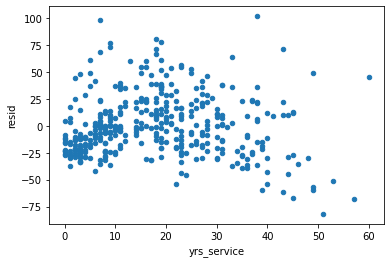

In [19]:
df["resid"] = m01.resid
df.plot.scatter(x = "yrs_service", y = "resid");

Судя по графику, точно **нельзя** сказать, что:

* нет связи между значениями независимой переменной и остатками (она есть и даже похожа на квадратичную);
* дисперсия остатков постоянна – одинакова при разных значениях независимой переменной (разброс точек вокруг `resid = 0` везде разный). 

Уже некоторые условия Гаусса-Маркова не выполняются. Проверим (визуально) нормальность распределения остатков. Для разнообразия посмотрим на *Q-Q plot*, который на лекциях вы называли нормальной вероятностной бумагой:

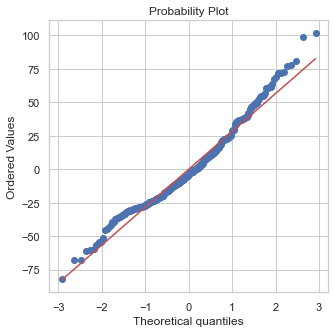

In [20]:
sns.set_theme(style = "whitegrid")
fig, ax = plt.subplots(figsize = (5, 5))

# probplot = Quantile-to-Quantile Plot
stats.probplot(df["resid"], dist = "norm", plot = ax);

Видно, что небольшие отклонения от нормальности есть, есть точки по краям, удаленные от диагонали, которая соответствует совпадению теоретических квантилей нормального распределения с выборочными квантилями.

### О графиках и «доверительной трубке» вокруг регрессионной прямой

Построим диаграмму рассеивания с добавленной на нее регрессионной прямой, используя возможности `seaborn`:

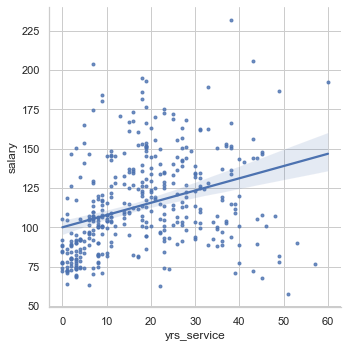

In [21]:
# lmplot: linear model plot

sns.lmplot(data = df, 
           x = "yrs_service", 
           y = "salary", 
           markers = '.');

Функция `lmplot()` дополнительно строит 95%-ную доверительную трубку для регрессионной прямой, отмечая границы, в которых с заданной уверенностью может лежать прямая при оценивании модели на иных выборках того же объёма.

Что тут видно? Прямая, в целом, проходит через облако точек, однако связь больше похожа на нелинейную. А точнее, на квадратичную, на растянутую параболу с ветвями вниз. Похожую картину мы видели и выше на диаграмме рассеивания для остатков. 

Проверим свои догадки с помощью другой функции `regplot()` и укажем, что хотим оценить взаимосвязь через многочлен второй степени (`order = 2`):

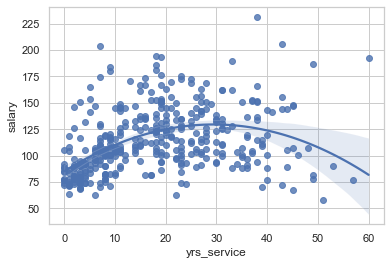

In [22]:
# regplot: regression model plot
# не только линейные модели

sns.regplot(data = df, 
            x = "yrs_service", 
            y = "salary", 
            order = 2);

Вот тут уже получше. Этот пример иллюстрирует классическую историю о нелинейной связи возраста (или опыта работы как следствие) и заработной платы. До какого-то момента увеличение возраста приводит к увеличению заработной платы, а потом, когда человек достигает пожилого возраста, наблюдается обратная зависимость в силу сокращения нагрузки, отставания от новых технологий и прочего.

Давайте выйдем за границы классической парной линейной модели и рассмотрим несколько дополнительных сюжетов «на будущее».

### Дополнительно: выход за рамки обычной парной линейной регрессии

**Сюжет 1.** Как учесть квадратичную зависимость в рамках линейной модели? Добавить переменную в квадрате, но не предварительно возведя значения в столбце в квадрат, а скорректировав формулу:

In [23]:
# I() означает – читай как есть, как отдельную переменную

m03 = ols("salary ~ yrs_service + I(yrs_service **2)", data = df).fit()
print(m03.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     53.74
Date:                Thu, 28 May 2026   Prob (F-statistic):           2.31e-21
Time:                        00:31:39   Log-Likelihood:                -1869.0
No. Observations:                 397   AIC:                             3744.
Df Residuals:                     394   BIC:                             3756.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              85.1554    

$R^2$ увеличился (но здесь это, скорее, по определению, у нас одна и та же переменная фигурирует дважды, хоть и «нелинейно»), но здесь важно другое. Коэффициент при квадратичной переменной `I(yrs_service ** 2)` значим, значит, квадратичная связь есть. При этом коэффициент при `yrs_service` положительный, а при `I(yrs_service ** 2)` – отрицательный, что и описывает параболу с ветвями вниз. До какого-то момента увеличение опыта работы (что созвучно увеличению возраста) приносит увеличение заработной платы, а потом – наоборот.

**Сюжет 2.** Как учесть качественный предиктор в модели? 

Если в модель добавляются текстовые переменные, `ols()` автоматически разбивает их на набор бинарных столбцов (*one-hot encoding*), и во избежание строгой линейной зависимости (мультиколлинеарности) в модель включает не все бинарные столбцы, а на один меньше. Категория, соответствующая единицам в бинарном столбце, не включенном в модель, считается *базовой*. По умолчанию базовая категория – первая по алфавиту в исходном текстовом столбце. 

Оценим модель, которая предсказывает заработную плату в зависимости от пола:

In [24]:
m04 = ols("salary ~ sex", data = df).fit()
print(m04.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     7.738
Date:                Thu, 28 May 2026   Prob (F-statistic):            0.00567
Time:                        00:31:40   Log-Likelihood:                -1913.0
No. Observations:                 397   AIC:                             3830.
Df Residuals:                     395   BIC:                             3838.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     101.0024      4.809     21.001      

В данном случае значения в `sex` были `Female` и `Male`, соответственно, были созданы бинарные столбцы `Female` и `Male`, категория `Female` стала базовой, а бинарный столбец `Male` был включен в модель. Отсюда `sex[T.Male]` в выдаче, `T.Male` расшифровывается как `True для Male`.

Коэффициент при предикторе `sex[T.Male]` показывает разницу в средних значениях заработной платы у женщин и мужчин. В данном случае годовая заработная плата мужчин, в среднем, на 14 тысяч долларов выше, чем у женщин, и эти различия статистически значимы (p-value = 0.006). Построение модели в такой спецификации эквивалентно реализации двухвыборочного критерия Стьюдента:

In [25]:
male = df[df["sex"] == "Male"]
female = df[df["sex"] == "Female"]

# разница в выборочных средний = коэффициент при sex выше
# t-наблюдаемое и p-value – как в выдаче выше

print(male["salary"].mean() - female["salary"].mean())
print(stats.ttest_ind(male["salary"], female["salary"]))

14.088008738003111
Ttest_indResult(statistic=2.7816740642624276, pvalue=0.005667106519338761)


**Сюжет 3.** Как учесть различия в эффекте независимой переменной на зависимую для разных групп? 

Посмотрим сначала на графики – построим отдельно диаграммы рассеивания для мужчин и женщин:

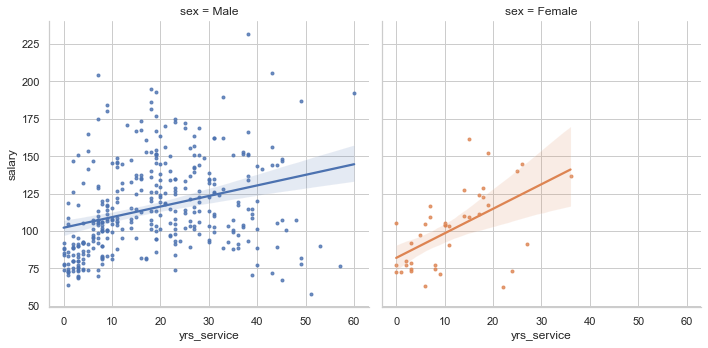

In [26]:
# hue – разный цвет точек и прямой для Female и Male
# col – графики в разных столбцах для Female и Male

sns.lmplot(data = df, 
           x = "yrs_service", 
           y = "salary", 
           markers = '.', 
           col = "sex", 
           hue = "sex");

Что видно? Средняя заработная плата женщин ниже (сравним значения `salary` при `yrs_service = 0`), однако у женщин эффект опыта работы на заработную плату более сильный (сравним углы наклона). То есть увеличение опыта работы на год сильнее сказывается на зарплате женщин. 

Если мы захотим проверить, насколько существенны различия в углах наклона, мы можем построить линейную модель с **эффектом взаимодействия** пола и опыта работы:

In [27]:
# yrs_service:sex

m05 = ols("salary ~ yrs_service + sex + yrs_service:sex", data = df).fit()
print(m05.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     18.98
Date:                Thu, 28 May 2026   Prob (F-statistic):           1.62e-11
Time:                        00:31:40   Log-Likelihood:                -1890.0
No. Observations:                 397   AIC:                             3788.
Df Residuals:                     393   BIC:                             3804.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Если смотреть только на значимость – можем согласиться, что хотя бы на 10% уровне значимости, коэффициент при эффекте взаимодействия все-таки значим, отличия в эффекте `yrs_service` у мужчин и женщин есть.

Взаимодействие (*interaction term*) – это произведение `yrs_service` и бинарной переменной для `sex`. Запишем уравнение такой модели:

$$\widehat{salary} = 82.07 + 20.13 × \text{Male} + 1.64 × \text{yrs_service} - 0.93 × \text{yrs_service} × \text{Male}
$$

Найдем предельный эффект переменной `yrs_service` на `salary` – частную производную по `yrs_service` от функции выше:

$$
\text{marginal effect} = 1.64 - 0.93 × \text{Male}
$$

Получается, эффект опыта работы на зарплату у мужчин (`Male = 1`) ниже на 0.93, чем у женщин. А это и есть коэффициент при переменной взаимодействия `yrs_service:sex[T.Male]`.

Предельные эффекты можно формировать и для двух количественных переменных тоже (перемножить можно что угодно), просто тогда без вычисления предельных эффектов в конкретных точках интерпретировать это будет сложнее.

**NB.** Если добавляем эффект взаимодействия, исходные переменные, которые входят в эффект (произведение), тоже обязательно должны включаться в модель, иначе она не имеет смысла.